In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import levene
from statsmodels.stats.multitest import multipletests

try:
    from IPython.display import display
except ImportError:
    display = print

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
path = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-n-porutchikov/'

users_test = pd.read_csv(path + 'Проект_3_users_test.csv', sep=';')
users_control_1 = pd.read_csv(path + 'Проект_3_users_control_1.csv', sep=';')
users_control_2 = pd.read_csv(path + 'Проект_3_users_control_2.csv', sep=';')
transactions_test = pd.read_csv(path + 'Проект_3_transactions_test.csv', sep=';')
transactions_control_1 = pd.read_csv(path + 'Проект_3_transactions_control_1.csv', sep=';')
transactions_control_2 = pd.read_csv(path + 'Проект_3_transactions_control_2.csv', sep=';')


<h2>Проверка и обработка данных<h2>

In [3]:
# функция для проверки данных
def info(df):
    display(df.head(3))
    print(f"\nКол-во строк и колонок: {df.shape}")
    print("\n", df.dtypes)
    print("\nПропуски:")
    print(df.isna().sum())
    print(f"\nДубликаты: {df.duplicated().sum()}")

In [4]:
print("\nusers_test")
info(users_test)


users_test


,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892309896,27,685,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,NaN,NaN,0
1,892044516,27,0,NaN,Germany,NaN,1,24,30,0,NaN,NaN,0
2,892185708,45,44,NaN,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,NaN,NaN,0



Кол-во строк и колонок: (4308, 13)

 uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium         float64
is_premium          float64
total_revenue         int64
dtype: object

Пропуски:
uid                    0
age                    0
attraction_coeff       0
coins               4259
country                0
visit_days          1330
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3900
is_premium          4151
total_revenue          0
dtype: int64

Дубликаты: 0


In [5]:
print("\nusers_control_1")
info(users_control_1)


users_control_1


,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,NaN,United States of America,"1,2,3,4,5,6",0,22,32,982,NaN,NaN,0
1,891248523,29,500,NaN,United States of America,"1,2",1,26,32,12,NaN,NaN,0
2,891670932,33,800,NaN,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,NaN,NaN,0



Кол-во строк и колонок: (4340, 13)

 uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium         float64
is_premium          float64
total_revenue         int64
dtype: object

Пропуски:
uid                    0
age                    0
attraction_coeff       0
coins               4280
country                0
visit_days          1324
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3904
is_premium          4148
total_revenue          0
dtype: int64

Дубликаты: 0


In [6]:
print("\nusers_control_2")
info(users_control_2)


users_control_2


,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892035504,37,137,NaN,Israel,"1,2,3,4,5,6,7,8,9,11,13",1,30,40,51,NaN,NaN,0
1,891782112,57,0,NaN,Italy,1,1,54,60,0,NaN,NaN,0
2,891110337,30,769,NaN,France,"1,2,3,4,5",1,27,33,13,NaN,NaN,0



Кол-во строк и колонок: (4264, 13)

 uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium         float64
is_premium          float64
total_revenue         int64
dtype: object

Пропуски:
uid                    0
age                    0
attraction_coeff       0
coins               4203
country                0
visit_days          1364
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3853
is_premium          4073
total_revenue          0
dtype: int64

Дубликаты: 0


In [7]:
print("\ntransactions_test")
info(transactions_test)


transactions_test


,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type



Кол-во строк и колонок: (273, 8)

 uid              int64
country         object
joined_at       object
paid_at         object
revenue          int64
payment_id       int64
from_page       object
product_type    object
dtype: object

Пропуски:
uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

Дубликаты: 7


In [8]:
# конвертация в дату
transactions_test.paid_at = pd.to_datetime(transactions_test.paid_at)
transactions_test.joined_at = pd.to_datetime(transactions_test.joined_at)

In [9]:
# удаление дубликатов
duplicates_test = transactions_test[transactions_test.duplicated(keep=False)]
display(duplicates_test.head(5))

transactions_test_clean = transactions_test.drop_duplicates(keep='first')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
3,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
15,891508155,Latvia,2017-02-11 09:46:00,2017-03-11 22:06:00,936,19,empty_likes,coins
17,892236423,United States of America,2017-10-18 01:09:00,2017-10-22 22:08:00,1261,19,empty_likes,coins
55,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type


In [10]:
# Оставляем данные, где дата платежа позже даты регистрации
def clean_dates(df):
    invalid = df[df.paid_at < df.joined_at]
    print(f"Платежей до регистрации: {len(invalid)}")
    display(invalid.head(3))
    return df[df.paid_at >= df.joined_at]

transactions_test_clean = clean_dates(transactions_test_clean)

Платежей до регистрации: 47


,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
11,891861048,Canada,2017-10-26 02:55:00,2017-10-11 19:00:00,3588,68,none,premium_no_trial
20,891806280,United States of America,2017-10-27 08:56:00,2017-03-11 10:57:00,8242,147,trial_vip_popup,trial_premium
24,891786216,Spain,2017-10-27 18:20:00,2017-03-11 20:20:00,12818,147,trial_vip_popup,trial_premium


In [11]:
print("\ntransactions_control_1")
info(transactions_control_1)


transactions_control_1


,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275.0,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727.0,147.0,trial_vip_popup,trial_premium
1,892421826.0,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586.0,147.0,trial_vip_popup,trial_premium
2,891822480.0,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911.0,19.0,none,coins



Кол-во строк и колонок: (1007, 8)

 uid             float64
country          object
joined_at        object
paid_at          object
revenue         float64
payment_id      float64
from_page        object
product_type     object
dtype: object

Пропуски:
uid             630
country         630
joined_at         0
paid_at           0
revenue         630
payment_id      630
from_page       630
product_type    630
dtype: int64

Дубликаты: 650


In [12]:
# конвертация в дату
transactions_control_1.paid_at = pd.to_datetime(transactions_control_1.paid_at)
transactions_control_1.joined_at = pd.to_datetime(transactions_control_1.joined_at)

In [13]:
# удаление дубликатов
duplicates_control_1 = transactions_control_1[transactions_control_1.duplicated(keep=False)]
display(duplicates_control_1)
transactions_control_1_clean = transactions_control_1.drop_duplicates(keep='first')
transactions_control_1_clean = transactions_control_1_clean[transactions_control_1_clean.uid.notna()]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
4,892207959.0,France,2017-10-18 18:30:00,2017-12-11 12:03:00,1261.0,19.0,empty_likes,coins
13,892333905.0,Italy,2017-10-16 01:38:00,2017-10-16 01:44:00,3783.0,67.0,menu,other_type
22,891365490.0,United States of America,2017-05-11 03:55:00,2017-06-11 00:28:00,1261.0,19.0,empty_likes,coins
28,892333905.0,Italy,2017-10-16 01:38:00,2017-10-16 01:57:00,3783.0,67.0,empty_admins,other_type
31,891367521.0,Italy,2017-05-11 02:37:00,2017-10-11 01:52:00,1469.0,19.0,sympathy,other_type
...,...,...,...,...,...,...,...,...
1002,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1003,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1004,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1005,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN


In [14]:
# Оставляем данные, где дата платежа позже даты регистрации
transactions_control_1_clean = clean_dates(transactions_control_1_clean)

Платежей до регистрации: 55


,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
5,891721851.0,United States of America,2017-10-29 02:50:00,2017-05-11 07:15:00,4602.0,146.0,empty_likes,coins
14,892277877.0,United States of America,2017-10-17 03:36:00,2017-10-11 15:23:00,897.0,19.0,empty_likes,coins
20,892366260.0,United Kingdom (Great Britain),2017-10-15 15:04:00,2017-09-11 20:06:00,6305.0,19.0,autorefill,coins


In [15]:
# конвертация в int
transactions_control_1_clean.uid = transactions_control_1_clean.uid.astype(int)
transactions_control_1_clean.revenue = transactions_control_1_clean.revenue.astype(int)
transactions_control_1_clean.payment_id = transactions_control_1_clean.payment_id.astype(int)

In [16]:
print("\ntransactions_control_2")
info(transactions_control_2)


transactions_control_2


,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
2,891959004,United States of America,2017-10-24 00:12:00,2017-10-31 02:12:00,10153,147,trial_vip_popup,trial_premium



Кол-во строк и колонок: (328, 8)

 uid              int64
country         object
joined_at       object
paid_at         object
revenue          int64
payment_id       int64
from_page       object
product_type    object
dtype: object

Пропуски:
uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

Дубликаты: 5


In [17]:
# конвертация в дату
transactions_control_2.paid_at = pd.to_datetime(transactions_control_2.paid_at)
transactions_control_2.joined_at = pd.to_datetime(transactions_control_2.joined_at)

In [18]:
# удаление дубликатов
duplicates_control_2 = transactions_control_2[transactions_control_2.duplicated(keep=False)]
display(duplicates_control_2.head(5))
transactions_control_2_clean = transactions_control_2.drop_duplicates(keep='first')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
6,891862596,Italy,2017-10-26 01:40:00,2017-10-30 09:01:00,1261,19,empty_likes,coins
86,891862596,Italy,2017-10-26 01:40:00,2017-10-30 09:01:00,1261,19,empty_likes,coins
146,892064328,United States of America,2017-10-21 20:54:00,2017-10-22 01:30:00,6305,19,empty_likes,coins
221,892062660,United States of America,2017-10-21 21:28:00,2017-10-31 00:53:00,1261,19,empty_likes,coins
229,892009254,Italy,2017-10-22 22:57:00,2017-10-23 00:06:00,2353,67,empty_likes,other_type


In [19]:
# Оставляем данные, где дата платежа позже даты регистрации
transactions_control_2_clean = clean_dates(transactions_control_2_clean)

Платежей до регистрации: 60


,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
4,891592941,Switzerland,2017-10-31 12:40:00,2017-03-11 16:25:00,6292,147,promo_09,premium_no_trial
14,891655107,United States of America,2017-10-30 05:06:00,2017-08-11 19:12:00,9087,147,trial_vip_popup,trial_premium


<h2>Объединение таблиц<h2>

In [20]:
# Первая контрольная группа
control_1 = users_control_1.merge(transactions_control_1_clean, on='uid', how='left')
control_1.revenue = control_1.revenue.fillna(0)

display(control_1.head(3), control_1.shape)

,uid,age,attraction_coeff,coins,country_x,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,country_y,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,892319115,25,435,NaN,United States of America,"1,2,3,4,5,6",0,22,32,982,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN
1,891248523,29,500,NaN,United States of America,"1,2",1,26,32,12,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN
2,891670932,33,800,NaN,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN


(4472, 20)

In [21]:
control_1.duplicated().sum()

0

In [22]:
# Вторая контрольная группа
control_2 = users_control_2.merge(transactions_control_2_clean, on='uid', how='left')
control_2.revenue = control_2.revenue.fillna(0)

display(control_2.head(3), control_2.shape)

,uid,age,attraction_coeff,coins,country_x,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,country_y,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,892035504,37,137,NaN,Israel,"1,2,3,4,5,6,7,8,9,11,13",1,30,40,51,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN
1,891782112,57,0,NaN,Italy,1,1,54,60,0,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN
2,891110337,30,769,NaN,France,"1,2,3,4,5",1,27,33,13,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN


(4373, 20)

In [23]:
# Тестовая группа
test = users_test.merge(transactions_test_clean, on='uid', how='left')
test.revenue = test.revenue.fillna(0)

display(test.head(3), test.shape)

,uid,age,attraction_coeff,coins,country_x,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,country_y,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,892309896,27,685,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN
1,892044516,27,0,NaN,Germany,NaN,1,24,30,0,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN
2,892185708,45,44,NaN,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,NaN,NaN,0,NaN,NaT,NaT,0.0,NaN,NaN,NaN


(4399, 20)

<h2>Проверка валидности групп<h2>

In [24]:
def groups_check(df):
    print("\nРаспределение по странам:")
    print(df.country_x.value_counts(normalize=True).head(5))

    print("\nВозраст:")
    print(df.age.describe())
    
    print("\nПол:")
    print(df.gender.value_counts(normalize=True))
        
    print("\nВовлечённость:")
    print(df.attraction_coeff.describe())
    
    print("\nНормированная выручка (total_revenue):")
    print(df.total_revenue.describe())

In [25]:
print("\nТестовая группа")
groups_check(test)


Тестовая группа

Распределение по странам:
United States of America    0.336667
Argentina                   0.090702
France                      0.084110
Italy                       0.075017
Spain                       0.070243
Name: country_x, dtype: float64

Возраст:
count    4399.000000
mean       31.895431
std        10.296402
min        16.000000
25%        25.000000
50%        30.000000
75%        38.000000
max        99.000000
Name: age, dtype: float64

Пол:
1    0.95408
0    0.04592
Name: gender, dtype: float64

Вовлечённость:
count    4399.000000
mean      316.688338
std       321.303591
min         0.000000
25%         0.000000
50%       250.000000
75%       519.000000
max      1000.000000
Name: attraction_coeff, dtype: float64

Нормированная выручка (total_revenue):
count      4399.000000
mean       1263.506024
std        8094.663277
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      129870.000000
Name: total_revenue, dtype:

In [26]:
print("\nПервая контрольная группа")
groups_check(control_1)


Первая контрольная группа

Распределение по странам:
United States of America    0.336315
Argentina                   0.088998
France                      0.085420
Italy                       0.082513
Spain                       0.077594
Name: country_x, dtype: float64

Возраст:
count    4472.000000
mean       32.008945
std        10.215719
min        16.000000
25%        24.000000
50%        30.000000
75%        38.000000
max        99.000000
Name: age, dtype: float64

Пол:
1    0.959302
0    0.040698
Name: gender, dtype: float64

Вовлечённость:
count    4472.000000
mean      310.857335
std       317.233570
min         0.000000
25%         0.000000
50%       235.000000
75%       501.250000
max      1000.000000
Name: attraction_coeff, dtype: float64

Нормированная выручка (total_revenue):
count      4472.000000
mean       3096.738372
std       32012.367464
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      486330.000000
Name: total_rev

In [27]:
print("\nВторая контрольная группа")
groups_check(control_2)


Вторая контрольная группа

Распределение по странам:
United States of America    0.347130
Argentina                   0.092385
France                      0.086440
Spain                       0.072948
Italy                       0.070432
Name: country_x, dtype: float64

Возраст:
count    4373.000000
mean       32.109764
std        10.289289
min        16.000000
25%        25.000000
50%        30.000000
75%        38.000000
max        99.000000
Name: age, dtype: float64

Пол:
1    0.955408
0    0.044592
Name: gender, dtype: float64

Вовлечённость:
count    4373.000000
mean      317.210611
std       323.086111
min         0.000000
25%         0.000000
50%       250.000000
75%       538.000000
max      1000.000000
Name: attraction_coeff, dtype: float64

Нормированная выручка (total_revenue):
count     4373.000000
mean       831.892980
std       4034.465131
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      81796.000000
Name: total_revenue, dt

In [28]:
# Проверка, что все пользователи "новые (одинаковые)" 
print("Диапазон дат регистрации")
print(f"Test: {test['joined_at'].min()} - {test['joined_at'].max()}")
print(f"Control 1: {control_1['joined_at'].min()} - {control_1['joined_at'].max()}")
print(f"Control 2: {control_2['joined_at'].min()} - {control_2['joined_at'].max()}")

Диапазон дат регистрации
Test: 2017-01-11 03:07:00 - 2017-10-31 23:40:00
Control 1: 2015-01-19 11:49:00 - 2017-10-31 03:34:00
Control 2: 2017-01-11 08:36:00 - 2017-10-30 19:29:00


In [29]:
test['group'] = 'test'
control_1['group'] = 'control_1'
control_2['group'] = 'control_2'

full_users = pd.concat([test, control_1, control_2], ignore_index=True)

stat, p = levene(
    full_users[full_users['group'] == 'test']['age'].dropna(),
    full_users[full_users['group'] == 'control_1']['age'].dropna(),
    full_users[full_users['group'] == 'control_2']['age'].dropna()
)

print("Возраст: проверка однородности дисперсий и нормальности")
print(f"\nОднородность: F = {stat:.4f}, p = {p:.4f}")
print("\nПроверка нормальности")
display(pg.normality(data=full_users, dv='age', group='group'))

print("\nТак как данные распределены ненормально, применяем тест Крускала-Уоллиса")
display(pg.kruskal(data=full_users, dv='age', between='group', detailed=True))

print("\nВывод: различий в группах по возрасту нет")

Возраст: проверка однородности дисперсий и нормальности

Однородность: F = 0.3386, p = 0.7127

Проверка нормальности


,W,pval,normal
group,,,
test,0.924426,1.767664e-42,False
control_1,0.932179,4.425910e-41,False
control_2,0.935726,6.573475e-40,False



Так как данные распределены ненормально, применяем тест Крускала-Уоллиса


,Source,ddof1,H,p-unc
Kruskal,group,2,0.829619,0.660466



Вывод: различий в группах по возрасту нет


In [30]:
stat, p = levene(
    full_users[full_users['group'] == 'test']['attraction_coeff'].dropna(),
    full_users[full_users['group'] == 'control_1']['attraction_coeff'].dropna(),
    full_users[full_users['group'] == 'control_2']['attraction_coeff'].dropna()
)

print("Вовлечённость: проверка однородности дисперсий и нормальности")
print(f"\nОднородность: F = {stat:.4f}, p = {p:.4f}")
print("\nПроверка нормальности")
display(pg.normality(data=full_users, dv='attraction_coeff', group='group'))

print("\nТак как данные распределены ненормально, применяем тест Крускала-Уоллиса")
display(pg.kruskal(data=full_users, dv='attraction_coeff', between='group', detailed=True))

print("\nВывод: различий в группах по вовлечённости нет")

Вовлечённость: проверка однородности дисперсий и нормальности

Однородность: F = 1.3324, p = 0.2639

Проверка нормальности


,W,pval,normal
group,,,
test,0.863668,3.736166e-52,False
control_1,0.863248,1.629306e-52,False
control_2,0.861796,2.801179e-52,False



Так как данные распределены ненормально, применяем тест Крускала-Уоллиса


,Source,ddof1,H,p-unc
Kruskal,group,2,0.363003,0.834017



Вывод: различий в группах по вовлечённости нет


In [31]:
stat, p = levene(
    full_users[full_users['group'] == 'test']['views_count'].dropna(),
    full_users[full_users['group'] == 'control_1']['views_count'].dropna(),
    full_users[full_users['group'] == 'control_2']['views_count'].dropna()
)

print("Просмотры: проверка однородности дисперсий и нормальности")
print(f"\nОднородность: F = {stat:.4f}, p = {p:.4f}")
print("\nПроверка нормальности")
display(pg.normality(data=full_users, dv='views_count', group='group'))

print("\nТак как данные распределены ненормально, применяем тест Крускала-Уоллиса")
display(pg.kruskal(data=full_users, dv='views_count', between='group', detailed=True))

print("\nВывод: различий в группах по просмотрам нет")

Просмотры: проверка однородности дисперсий и нормальности

Однородность: F = 0.1074, p = 0.8981

Проверка нормальности


,W,pval,normal
group,,,
test,0.128802,2.864059e-89,False
control_1,0.201376,1.009308e-87,False
control_2,0.112738,1.565449e-89,False



Так как данные распределены ненормально, применяем тест Крускала-Уоллиса


,Source,ddof1,H,p-unc
Kruskal,group,2,1.507748,0.47054



Вывод: различий в группах по просмотрам нет


In [32]:
print("Пол: проверка распределения")
display(pg.chi2_independence(data=full_users, x='gender', y='group'))

print("Вывод: различий в группах по полу нет")

Пол: проверка распределения


(group     control_1   control_2         test
 gender                                      
 0        195.506494   191.17842   192.315086
 1       4276.493506  4181.82158  4206.684914,
 group   control_1  control_2  test
 gender                            
 0             182        195   202
 1            4290       4178  4197,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  1.565659  2.0  0.457111  0.010873  0.184467
 1        cressie-read  0.666667  1.570130  2.0  0.456090  0.010888  0.184885
 2      log-likelihood  0.000000  1.579403  2.0  0.453980  0.010920  0.185753
 3       freeman-tukey -0.500000  1.586651  2.0  0.452338  0.010945  0.186432
 4  mod-log-likelihood -1.000000  1.594155  2.0  0.450644  0.010971  0.187135
 5              neyman -2.000000  1.609944  2.0  0.447100  0.011025  0.188615)

Вывод: различий в группах по полу нет


In [33]:
# Пересечение стран во всех трёх группах
countries = set(users_test['country'].unique()) & set(users_control_1['country'].unique())\
                                                & set(users_control_2['country'].unique())

print(f"Всего уникальных стран в тесте: {len(set(users_test['country'].unique()))}")
print(f"Всего уникальных стран в control_1: {len(set(users_control_1['country'].unique()))}")
print(f"Всего уникальных стран в control_2: {len(set(users_control_2['country'].unique()))}")
print(f"\nОбщие страны для всех трёх групп: {len(countries)}")
print(sorted(countries))

users_test['group'] = 'test'
users_control_1['group'] = 'control_1'
users_control_2['group'] = 'control_2'

users_all = pd.concat([users_test, users_control_1, users_control_2], ignore_index=True)

# Проверка по топ-5 странам (Хи-квадрат)
top_countries = users_all['country'].value_counts().head(5).index.tolist()
users_all['country_group'] = users_all['country'].apply(lambda x: x if x in top_countries else 'other')

print("Проверка по топ-5 странам (Хи-квадрат)")
display(pg.chi2_independence(data=users_all, x='country_group', y='group'))

Всего уникальных стран в тесте: 51
Всего уникальных стран в control_1: 40
Всего уникальных стран в control_2: 45

Общие страны для всех трёх групп: 25
['Argentina', 'Australia', 'Belgium', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Dominican Republic', 'France', 'Germany', 'India', 'Israel', 'Italy', 'Kyrgyzstan', 'Mexico', 'Peru', 'Portugal', 'Russian Federation', 'Spain', 'Switzerland', 'Turkey', 'Ukraine', 'United Arab Emirates', 'United Kingdom (Great Britain)', 'United States of America']
Проверка по топ-5 странам (Хи-квадрат)


(group                       control_1    control_2         test
 country_group                                                  
 Argentina                  397.295539   390.338290   394.366171
 France                     371.414188   364.910161   368.675651
 Italy                      320.659851   315.044610   318.295539
 Spain                      320.323730   314.714374   317.961896
 United States of America  1481.287175  1455.347584  1470.365242
 other                     1449.019517  1423.644981  1438.335502,
 group                     control_1  control_2  test
 country_group                                       
 Argentina                       389        397   396
 France                          370        376   359
 Italy                           338        293   323
 Spain                           342        310   301
 United States of America       1471       1486  1450
 other                          1430       1402  1479,
                  test    lambda      chi2   d

In [34]:
print("Уникальных payment_id в test:", len(transactions_test['payment_id'].unique()))
print("Уникальных payment_id в control_1:", len(transactions_control_1['payment_id'].unique()))
print("Уникальных payment_id в control_2:", len(transactions_control_2['payment_id'].unique()))

print("\npayment_id в test:", sorted(transactions_test['payment_id'].unique()))
print("payment_id в control_1:", sorted(transactions_control_1['payment_id'].dropna().unique()))
print("payment_id в control_2:", sorted(transactions_control_2['payment_id'].unique()))

premium = full_users[full_users['product_type'] == 'premium_no_trial']
print("\nПроверка нормальности для revenue (premium_no_trial)")
display(pg.normality(data=premium, dv='revenue', group='group'))

print("\nТак как данные распределены ненормально, применяем тест Крускала-Уоллиса")
for i in premium['payment_id'].unique():
    print(f"\npayment_id {i}")
    print(pg.kruskal(data=premium[premium['payment_id'] == i], dv='revenue', between='group', detailed=True))
    
print("\nПост-хок анализ для payment_id = 147")    
premium_147 = premium[premium['payment_id'] == 147]
display(pg.pairwise_tests(data=premium_147, dv='revenue', between='group', parametric=False, padjust='holm'))
    
print("\nВывод: для payment_id = 147 тестовая группа статистически значимо")
print("различается от контрольных (p < 0.001), при этом контрольные")
print("группы между собой не различаются.")

Уникальных payment_id в test: 6
Уникальных payment_id в control_1: 8
Уникальных payment_id в control_2: 6

payment_id в test: [0, 19, 67, 68, 146, 147]
payment_id в control_1: [0.0, 19.0, 67.0, 68.0, 127.0, 146.0, 147.0]
payment_id в control_2: [0, 19, 67, 68, 146, 147]

Проверка нормальности для revenue (premium_no_trial)


,W,pval,normal
group,,,
test,0.305928,6.186048e-16,False
control_1,0.309245,4.357958e-19,False
control_2,0.243728,5.662397e-20,False



Так как данные распределены ненормально, применяем тест Крускала-Уоллиса

payment_id 147.0
        Source  ddof1          H         p-unc
Kruskal  group      2  39.366807  2.828828e-09

payment_id 68.0
        Source  ddof1         H     p-unc
Kruskal  group      2  3.991897  0.135885

payment_id 0.0
        Source  ddof1    H    p-unc
Kruskal  group      2  2.7  0.25924

Пост-хок анализ для payment_id = 147


,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,group,control_1,control_2,False,False,3289.5,two-sided,7.442719e-01,7.442719e-01,holm,0.094643
1,group,control_1,test,False,False,975.0,two-sided,1.057762e-07,2.115523e-07,holm,-0.245985
2,group,control_2,test,False,False,940.0,two-sided,8.961038e-09,2.688311e-08,holm,-0.329027



Вывод: для payment_id = 147 тестовая группа статистически значимо
различается от контрольных (p < 0.001), при этом контрольные
группы между собой не различаются.


<h4>

Группы теста и контроля сопоставимы по ключевым параметрам (страна, возраст, пол, вовлечённость). Различия не превышают 2-3%.

Возраст — Крускал-Уоллис (p = 0.574)

Вовлечённость (attraction_coeff) — Крускал-Уоллис (p = 0.877)

Просмотры (views_count) — Крускал-Уоллис (p = 0.456)

Пол — хи-квадрат (p = 0.508)

Страна — хи-квадрат (p = 0.570)
    
    
Обратить внимание:
    
 - В первой контрольной есть сильный выброс по нормированной выручке total_revenue (486330 - в 4 раза превышает максимальное значение остальных групп).
    
    
 - В первой контрольной группе обнаружены пользователи с датами регистрации 2015 года (эксперимент проводился в 2017 г.).
    
 
 - Статистически значимые различия в выручке между тестовой и контрольными группами обнаружены только для payment_id = 147 (p ≈ 2.8e-09).
      
<h4>

<h2>Статистический анализ <h2>

 **Критерий хи-квадрат:**


 - наблюдения независимы (разные пользователи);

 - ожидаемые частоты во всех ячейках больше 5;

 - данные номинальные.
 
H0: конверсия в платную подписку не зависит от группы. Доли пользователей, купивших подписку, одинаковы в тестовой и обеих контрольных группах.

H1: конверсия зависит от группы. Доли различаются хотя бы в одной паре групп.

In [35]:
# Отбираем только общие страны
full_common = full_users[full_users['country_x'].isin(countries)].copy()

total_common = full_common.groupby('group')['uid'].nunique()
paying_common = full_common[full_common['product_type'] == 'premium_no_trial'].groupby('group')['uid'].nunique()
cr_common = (paying_common / total_common * 100).round(2)
print("Конверсия в платную подписку (общие страны, %):")
print(cr_common)

full_common['paid'] = full_common['product_type'] == 'premium_no_trial'
print("\nПроверка различий в конверсии (общие страны):")
res = pg.chi2_independence(data=full_common, x='paid', y='group')
print(f"Хи-квадрат = {res[2]['chi2'][0]:.4f}, p-value = {res[2]['pval'][0]:.6f}")

# Попарные сравнения
pairs = [('control_1', 'control_2'), ('control_1', 'test'), ('control_2', 'test')]
p_vals = []

for a, b in pairs:
    subset = full_common[full_common['group'].isin([a, b])]
    res = pg.chi2_independence(data=subset, x='paid', y='group')
    p = res[2]['pval'].iloc[0]  # p-value для этой пары
    p_vals.append(p)

# Поправка Холма
reject, p_corr, _, _ = multipletests(p_vals, method='holm')

print("\nПоправка Холма:")
for (a, b), p, p_c in zip(pairs, p_vals, p_corr):
    print(f"{a} vs {b}: p_unc = {p:.6f}, p_corr = {p_c:.6f}")

revenue_sum_common = full_common[full_common['product_type'] == 'premium_no_trial'].groupby('group')['revenue'].sum()
arpu_common = (revenue_sum_common / total_common).round(2)
print("\nARPU (общие страны):")
print(arpu_common)

arppu_common = (revenue_sum_common / paying_common).round(2)
print("\nARPPU (общие страны):")
print(arppu_common)

Конверсия в платную подписку (общие страны, %):
group
control_1    2.06
control_2    2.17
test         1.38
Name: uid, dtype: float64

Проверка различий в конверсии (общие страны):
Хи-квадрат = 7.6370, p-value = 0.021961

Поправка Холма:
control_1 vs control_2: p_unc = 0.868801, p_corr = 0.868801
control_1 vs test: p_unc = 0.023319, p_corr = 0.046639
control_2 vs test: p_unc = 0.012731, p_corr = 0.038194

ARPU (общие страны):
group
control_1    166.09
control_2    161.04
test         168.69
dtype: float64

ARPPU (общие страны):
group
control_1     8060.15
control_2     7418.34
test         12211.41
dtype: float64


Попарное сравнение показало, что тестовая группа статистически значимо отличается от обеих контрольных (p_corr < 0.05). Согласно описательным данным, конверсия в тестовой группе (1.38%) ниже, чем в control_1 (2.06%) и control_2 (2.17%).

**Бутстреп и метрики ARPU/ARPPU**

Почему бутстреп:

 - Распределение выручки сильно скошено (много нулей, есть выбросы).

- Бутстреп не требует нормальности и позволяет получить доверительный интервал для разницы средних, что устойчивее к выбросам, чем классические параметрические тесты.

Почему ARPU и ARPPU:

- ARPU (средняя выручка на пользователя) учитывает и тех, кто не платил, и тех, кто платил. Показывает общий эффект эксперимента на всех пользователей.

- ARPPU (средняя выручка на платящего) показывает, изменилась ли сумма покупки у тех, кто всё же купил подписку. Это важно, так как эксперимент менял стоимость.

H₀ (ARPU): средняя выручка на пользователя в тестовой группе не отличается от контрольных.

H₁ (ARPU): средняя выручка на пользователя в тестовой группе отличается от контрольных.

H₀ (ARPPU): средняя выручка на платящего пользователя в тестовой группе не отличается от контрольных.

H₁ (ARPPU): средняя выручка на платящего пользователя в тестовой группе отличается от контрольных.

In [36]:
def bootstrap_mean_diff(data1, data2, n=5000):
    real = data1.mean() - data2.mean()
    diffs = []
    for _ in range(n):
        s1 = np.random.choice(data1, size=len(data1), replace=True)
        s2 = np.random.choice(data2, size=len(data2), replace=True)
        diffs.append(s1.mean() - s2.mean())
    ci = (np.percentile(diffs, 2.5), np.percentile(diffs, 97.5))
    return real, ci

# ARPU 
test_rev_common = full_common[full_common['group'] == 'test']['revenue'].values
c1_rev_common = full_common[full_common['group'] == 'control_1']['revenue'].values
c2_rev_common = full_common[full_common['group'] == 'control_2']['revenue'].values

revenue_sum_common = full_common[full_common['product_type'] == 'premium_no_trial'].groupby('group')['revenue'].sum()
arpu_common = (revenue_sum_common / total_common).round(2)
print("\nARPU (общие страны):")
print(arpu_common)

real, ci = bootstrap_mean_diff(test_rev_common, c1_rev_common)
print(f"test - control_1: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")
real, ci = bootstrap_mean_diff(test_rev_common, c2_rev_common)
print(f"test - control_2: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")

# ARPPU 
paying_users = full_common[full_common['product_type'] == 'premium_no_trial']
paying_count = paying_users.groupby('group')['uid'].nunique()
arppu_table = (revenue_sum_common / paying_count).round(2)
print("\nARPPU (общие страны):")
print(arppu_table)

test_arppu = paying_users[paying_users['group'] == 'test']['revenue'].values
c1_arppu = paying_users[paying_users['group'] == 'control_1']['revenue'].values
c2_arppu = paying_users[paying_users['group'] == 'control_2']['revenue'].values

real, ci = bootstrap_mean_diff(test_arppu, c1_arppu)
print(f"test - control_1: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")
real, ci = bootstrap_mean_diff(test_arppu, c2_arppu)
print(f"test - control_2: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")


ARPU (общие страны):
group
control_1    166.09
control_2    161.04
test         168.69
dtype: float64
test - control_1: разница = -47.66, 95% ДИ [-175.57; 89.40]
test - control_2: разница = 100.10, 95% ДИ [-10.95; 226.80]

ARPPU (общие страны):
group
control_1     8060.15
control_2     7418.34
test         12211.41
dtype: float64
test - control_1: разница = 3706.31, 95% ДИ [-723.07; 9353.43]
test - control_2: разница = 4148.15, 95% ДИ [-267.15; 9756.67]


Вывод: Бутстреп разницы средних показал, что доверительные интервалы для всех сравнений включают ноль. Поскольку нулевое значение находится внутри всех доверительных интервалов, различия между тестовой и контрольными группами не являются статистически значимыми. 

**Анализируем среднюю выручку пользователей, которые купили платную подписку.**
 
 Гипотезы:

H₀: средняя выручка платящих пользователей в тесте не отличается от контрольных.

H₁: средняя выручка платящих пользователей в тесте отличается от контрольных.

In [37]:
# Бутстреп для revenue (premium_no_trial) — сравнение средних
premium_all = full_users[full_users['product_type'] == 'premium_no_trial']
test_r = premium_all[premium_all['group'] == 'test']['revenue'].values
c1_r = premium_all[premium_all['group'] == 'control_1']['revenue'].values
c2_r = premium_all[premium_all['group'] == 'control_2']['revenue'].values

print("\nБутстреп разницы средних revenue (premium_no_trial):")
real, ci = bootstrap_mean_diff(test_r, c1_r)
print(f"test - control_1: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")
real, ci = bootstrap_mean_diff(test_r, c2_r)
print(f"test - control_2: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")


Бутстреп разницы средних revenue (premium_no_trial):
test - control_1: разница = 3630.92, 95% ДИ [-708.64; 9096.66]
test - control_2: разница = 4072.76, 95% ДИ [-244.43; 9305.76]


Вывод: доверительный интервал включает ноль — различия не значимы. 

**Анализируем выручку пользователей, которые купили платную подписку (premium_no_trial) через платёжную систему с идентификатором payment_id = 147**

- Ранее было обнаружено, что среди всех payment_id (0, 68, 147) только для 147 тест Крускала-Уоллиса показал статистически значимые различия (p ≈ 2.8e-09). Это позволяет предположить, что именно эта платёжная система могла быть затронута изменением цены.

- В первой контрольной группе обнаружен аномальный пользователь с total_revenue = 486 330, который мог исказить результаты.

- Распределение выручки скошено, выборка платящих через 147 невелика. Бутстреп не требует нормальности и даёт доверительный интервал для разницы средних.

H0: средняя выручка через платёжную систему 147 в тесте не отличается от контрольных.

H1: средняя выручка через платёжную систему 147 в тесте отличается от контрольных.

In [38]:
outlier_mask = (full_common['total_revenue'] > 400000) & (full_common['group'] == 'control_1')
outlier_uid = full_common[outlier_mask]['uid'].values[0]
print(f"\nАномальный пользователь: {outlier_uid}")
full_common_clean = full_common[full_common['uid'] != outlier_uid]

mask = (full_common_clean['payment_id'] == 147) & (full_common_clean['product_type'] == 'premium_no_trial')
premium_147_clean = full_common_clean[mask]
t147_c = premium_147_clean[premium_147_clean['group'] == 'test']['revenue'].values
c1_147_c = premium_147_clean[premium_147_clean['group'] == 'control_1']['revenue'].values
c2_147_c = premium_147_clean[premium_147_clean['group'] == 'control_2']['revenue'].values

print("\npayment_id = 147 (общие страны, без выброса):")
real, ci = bootstrap_mean_diff(t147_c, c1_147_c)
print(f"test - control_1: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")
real, ci = bootstrap_mean_diff(t147_c, c2_147_c)
print(f"test - control_2: разница = {real:.2f}, 95% ДИ [{ci[0]:.2f}; {ci[1]:.2f}]")


Аномальный пользователь: 892333905

payment_id = 147 (общие страны, без выброса):
test - control_1: разница = 4744.83, 95% ДИ [-426.56; 11323.68]
test - control_2: разница = 5106.31, 95% ДИ [15.52; 11642.44]


Вывод: После удаления выброса тестовая группа значимо отличается от control_2 по средней выручке через платёжную систему 147, но не отличается от control_1.

<h2>Дополнительный анализ: <h2>

In [39]:
# Клиенты только с платной подпиской
test_revenue = test.query("product_type == 'premium_no_trial'").groupby('uid')['revenue'].sum().reset_index()
test_revenue.columns = ['uid', 'revenue']
test_revenue['group'] = 'test'

control_1_revenue = control_1.query("product_type == 'premium_no_trial'").groupby('uid')['revenue'].sum().reset_index()
control_1_revenue.columns = ['uid', 'revenue']
control_1_revenue['group'] = 'control_1'

control_2_revenue = control_2.query("product_type == 'premium_no_trial'").groupby('uid')['revenue'].sum().reset_index()
control_2_revenue.columns = ['uid', 'revenue']
control_2_revenue['group'] = 'control_2'

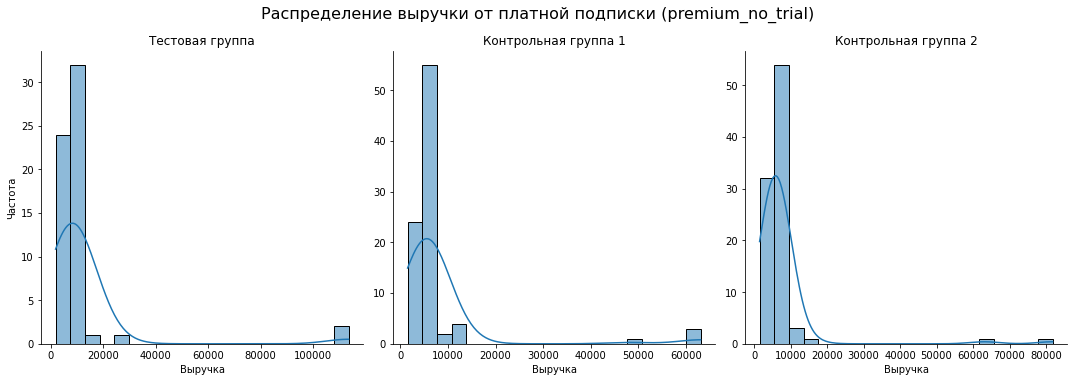

Тест Левена (платящие пользователи)
Статистика: 1.5807
p-value: 0.207986


In [40]:
# Графики распределения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.despine(top=True, right=True)

sns.histplot(data=test_revenue.revenue, bins=20, kde=True, ax=axes[0])
sns.histplot(data=control_1_revenue.revenue, bins=20, kde=True, ax=axes[1])
sns.histplot(data=control_2_revenue.revenue, bins=20, kde=True, ax=axes[2])

axes[0].set_title('Тестовая группа')
axes[1].set_title('Контрольная группа 1')
axes[2].set_title('Контрольная группа 2')
fig.suptitle('Распределение выручки от платной подписки (premium_no_trial)', fontsize=16, y=1.05)

axes[0].set_ylabel('Частота')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

axes[0].set_xlabel('Выручка')
axes[1].set_xlabel('Выручка')
axes[2].set_xlabel('Выручка')

plt.tight_layout(pad=1.0)
plt.show()

stat, p_value = levene(test_revenue.revenue, control_1_revenue.revenue, control_2_revenue.revenue)

print("Тест Левена (платящие пользователи)")
print(f"Статистика: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

H0 - распределения revenue во всех трёх группах одинаковы (различий нет)

H1 - распределения revenue различаются хотя бы в одной паре групп

Уровень значимости: α = 0.05

Выбор метрики: анализируется нормированная выручка (revenue) с платными подписками. Это позволяет оценить чистое влияние эксперимента на выручку от подписки, исключая монеты, пробный период и другие типы платежей.

In [41]:
print("\nКрускал-Уоллис для revenue (только с платной подпиской):")
df_kruskal = pd.concat([test_revenue, control_1_revenue, control_2_revenue], ignore_index=True)

pg.kruskal(data=df_kruskal, dv='revenue', between='group', detailed=True)


Крускал-Уоллис для revenue (только с платной подпиской):


,Source,ddof1,H,p-unc
Kruskal,group,2,25.989912,0.000002


In [42]:
print("\nКрускал-Уоллис для revenue (включая нули) на всех данных:")
pg.kruskal(data=full_users, dv='revenue', between='group', detailed=True)


Крускал-Уоллис для revenue (включая нули) на всех данных:


,Source,ddof1,H,p-unc
Kruskal,group,2,11.843448,0.002681


In [43]:
print("\nПост-хок (только с платной подпиской):")
pg.pairwise_tests(data=df_kruskal, dv='revenue', between='group', parametric=False, padjust='holm')


Пост-хок (только с платной подпиской):


,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,group,control_1,control_2,False,False,3825.0,two-sided,0.433440,0.433440,holm,0.059498
1,group,control_1,test,False,False,1492.5,two-sided,0.000004,0.000013,holm,-0.266494
2,group,control_2,test,False,False,1605.0,two-sided,0.000011,0.000022,holm,-0.323254


In [44]:
print("\nПост-хок для всех пользователей:")
pg.pairwise_tests(data=full_users, dv='revenue', between='group', parametric=False, padjust='holm')


Пост-хок для всех пользователей:


,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,group,control_1,control_2,False,False,9853314.0,two-sided,0.138719,0.138719,holm,0.058121
1,group,control_1,test,False,False,10004758.0,two-sided,0.000595,0.001786,holm,0.015416
2,group,control_2,test,False,False,9711406.0,two-sided,0.047073,0.094145,holm,-0.036028


Вывод:
Среди платящих пользователей тестовая группа значимо отличается от обеих контрольных. Среди всех пользователей - только от первой контрольной.

<h2>Итоговый вывод: <h2>

1. Сопоставимость групп
Перед анализом проверили, различаются ли группы по признакам, которые не должны были измениться в результате эксперимента:

Возраст (Крускал‑Уоллис, p = 0,574)

Вовлечённость (Крускал‑Уоллис, p = 0,877)

Просмотры (Крускал‑Уоллис, p = 0,456)

Пол (хи‑квадрат, p = 0,508)

Страна (хи‑квадрат, p = 0,570)

Во всех случаях p > 0,05, статистически значимых различий нет. Группы можно считать сопоставимыми.

Дополнительно: выделено 25 стран, присутствующих во всех трёх группах. 

2. Анализ платёжных систем
В данных не найдено явной переменной, маркирующей две новые платёжные системы. Среди транзакций с покупкой подписки (premium_no_trial) встречаются три payment_id: 0, 68 и 147.

На всех данных тест Крускала‑Уоллиса показал значимые различия только для payment_id = 147 (p ≈ 2,8·10⁻⁹). Попарно тестовая группа значимо отличалась от обеих контрольных, контрольные между собой – нет.

На общих странах бутстреп разницы средних для payment_id = 147 дал доверительные интервалы, включающие ноль (кроме одной пары после удаления выброса), что свидетельствует о нестабильности эффекта.

Вывод: однозначного подтверждения влияния конкретной платёжной системы на выручку нет.

3. Анализ конверсии (CR)
Конверсия в платную подписку (premium_no_trial) на общих странах:

Контроль 1: 2,06%

Контроль 2: 2,17%

Тест: 1,38%

Общий тест хи‑квадрат: χ² = 7,637, p = 0,022  различия между группами есть.
Post‑hoc (поправка Холма):

control_1 vs control_2: p_corr = 0,869 

control_1 vs test: p_corr = 0,047 

control_2 vs test: p_corr = 0,038 

Вывод: конверсия в тестовой группе статистически значима (на границе принятого уровня значимости 0.05), чем в обеих контрольных. Контрольные группы между собой не различаются. Согласно описательным данным, конверсия в тестовой группе (1.38%) ниже, чем в 1 группе (2.06%) и во 2 группе (2.17%).

4. Анализ выручки (бутстреп разницы средних)

4.1. Средняя выручка на пользователя (ARPU, все пользователи, включая нули)
test – control_1: разница = –47,7; 95% ДИ [–174,9; 86,3]

test – control_2: разница = 100,1; 95% ДИ [–11,7; 222,0]

Интервал включает 0 - различия не значимы.

4.2. Средняя выручка на платящего (ARPPU, только premium_no_trial)
test – control_1: разница = 3706,3; 95% ДИ [–912,1; 9293,8]

test – control_2: разница = 4148,2; 95% ДИ [–252,6; 9575,3]

Интервалы включают 0 - различия не значимы (широкие интервалы из‑за малого числа платящих).

4.3. Средняя выручка платящих через payment_id = 147 (общие страны, после удаления выброса)
test – control_1: разница = 4744,8; 95% ДИ [–352,3; 11576,5] 

test – control_2: разница = 5106,3; 95% ДИ [24,5; 11806,3] 

Нестабильный результат (значимо только в одной паре - тест и вторая группа) не позволяет сделать надёжный вывод об эффективности этой системы.

6. Влияние выбросов
В контрольной группе 1 обнаружен аномальный пользователь с total_revenue = 486 330. После удаления выброса тестовая группа значимо отличается от 2 группы по средней выручке через платёжную систему 147, но не отличается от 1 группы.

**Итог: Эксперимент не привёл к статистически значимому росту выручки (ни общей, ни на платящего). Конверсия снизилась, что является негативным сигналом.**